### 作者：东哥起飞

### 本篇文章来源于[《100天成为风控专家》](https://app7hmmvkwr2019.h5.xiaoeknow.com/p/course/ecourse/course_2ZAoFMNREbOv3DutKsoIi9Vlfky) 贷前策略篇-规则集性能测试(2):Python实操

In [1]:
import pandas as pd
import numpy as np
import scorecardpy as sc
from sklearn import tree
from sklearn.tree import _tree
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pydotplus
import seaborn as sns
from matplotlib import pyplot as plt
import os, re, sys
%matplotlib inline
## 设置属性防止中文乱码
plt.rcParams['font.sans-serif'] = [u'SimHei']
plt.rcParams['axes.unicode_minus'] = False

import warnings
warnings.filterwarnings("ignore")

In [2]:
import sklearn as sk
import matplotlib as mpl
print('python:%s'%(sys.version))
print('sklearn:%s'%(sk.__version__))
print('pandas:%s'%(pd.__version__))
print('numpy:%s'%(np.__version__))
print('matplotlib:%s'%(mpl.__version__))
print('seaborn:%s'%(sns.__version__))
print('scorecardpy:%s'%(sc.__version__))

python:3.8.5 (default, Sep  3 2020, 21:29:08) [MSC v.1916 64 bit (AMD64)]
sklearn:1.3.2
pandas:2.0.0
numpy:1.23.5
matplotlib:3.7.1
seaborn:0.12.2
scorecardpy:0.1.9.7


# 1.数据探索

前面数据探索不是重点，仅为初步筛选和描述性统计。
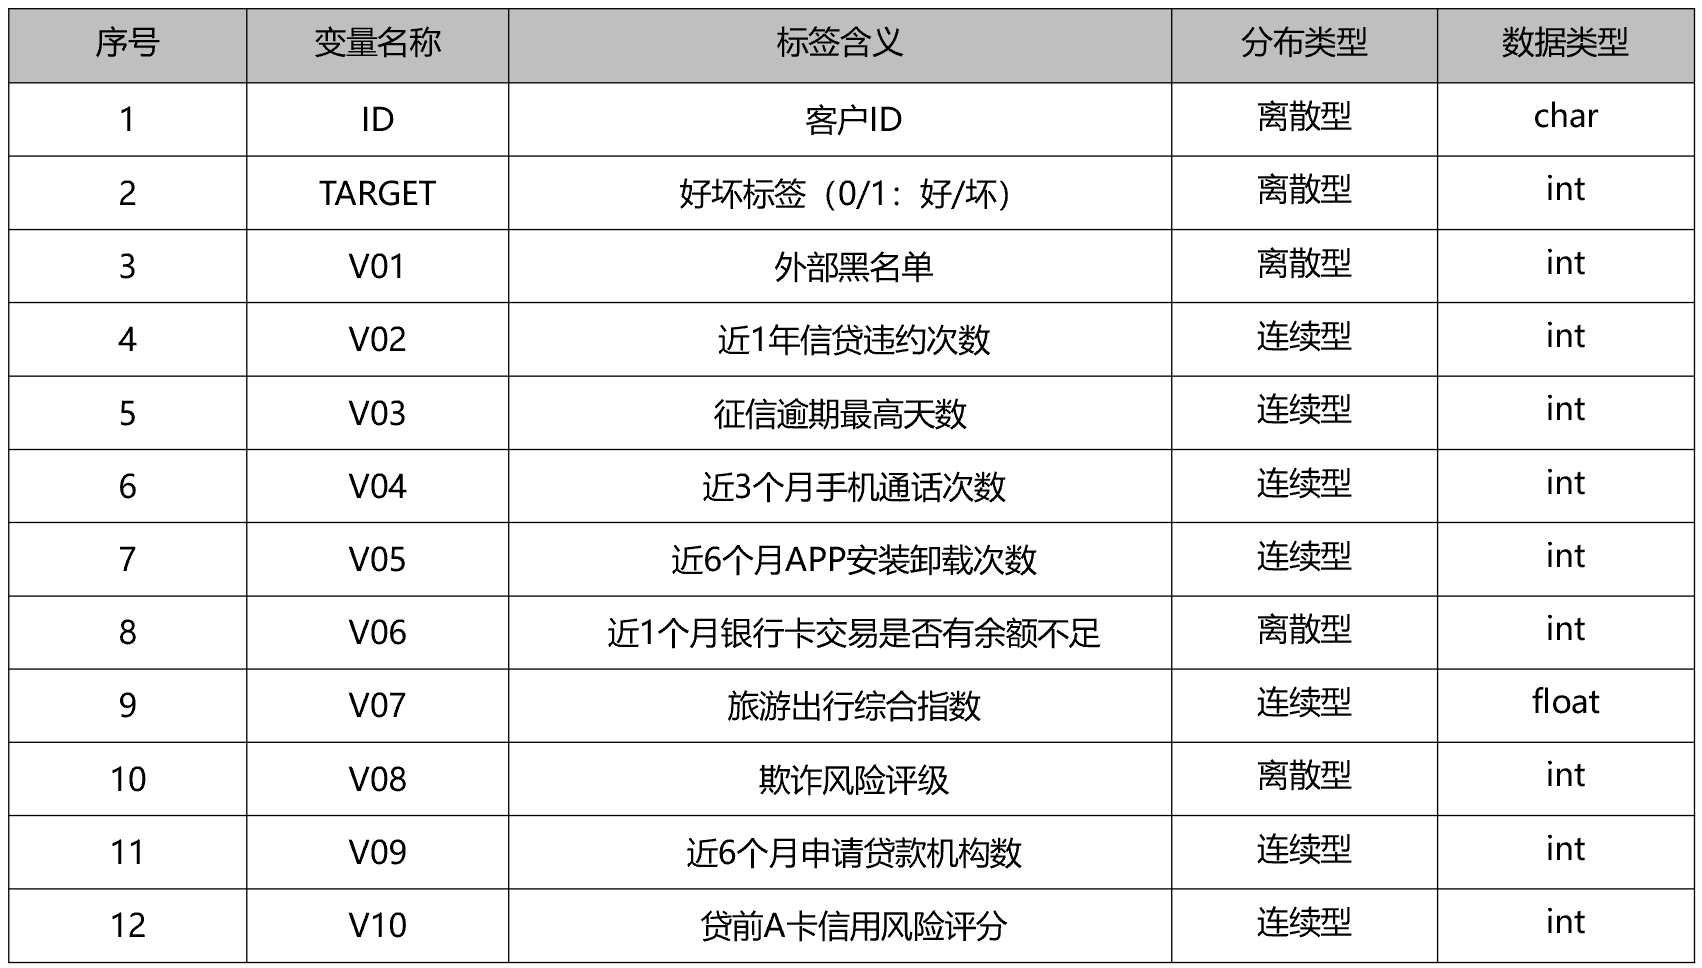

In [61]:
df = pd.read_excel('100daysrisk_strategy_ruleset.xlsx')
df.shape

(10000, 12)

In [62]:
df.describe()

,V01,V02,V03,V04,V05,V06,V07,V08,V09,V10,TARGET
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,0.060000,0.809700,0.370000,13.333600,29.70000,0.040000,4.603628,0.310000,0.879900,554.282700,0.185100
std,0.237499,1.830853,1.016466,12.770709,52.10702,0.195969,0.308195,0.688438,2.099075,35.042988,0.388398
min,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,4.020000,0.000000,0.000000,487.000000,0.000000
25%,0.000000,0.000000,0.000000,1.000000,0.00000,0.000000,4.302500,0.000000,0.000000,528.750000,0.000000
50%,0.000000,0.000000,0.000000,12.000000,12.00000,0.000000,4.680000,0.000000,0.000000,548.000000,0.000000
75%,0.000000,1.000000,0.000000,21.000000,29.00000,0.000000,4.830000,0.000000,0.000000,582.000000,0.000000
max,1.000000,12.000000,5.000000,62.000000,319.00000,1.000000,5.610000,3.000000,12.000000,632.000000,1.000000


In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      10000 non-null  object 
 1   V01     10000 non-null  int64  
 2   V02     10000 non-null  int64  
 3   V03     10000 non-null  int64  
 4   V04     10000 non-null  int64  
 5   V05     10000 non-null  int64  
 6   V06     10000 non-null  int64  
 7   V07     10000 non-null  float64
 8   V08     10000 non-null  int64  
 9   V09     10000 non-null  int64  
 10  V10     10000 non-null  int64  
 11  TARGET  10000 non-null  int64  
dtypes: float64(1), int64(10), object(1)
memory usage: 937.6+ KB


In [64]:
def simple_statics(df):
    # 读入数据
    stats = []
    for col in df.columns:
        stats.append((col, df[col].nunique(), 
                      (df[col].isnull()).sum() * 100 / df.shape[0],
                      df[col].value_counts(normalize=True, dropna=False).values[0] * 100, 
                      df[col].dtype))

    stats_df = pd.DataFrame(stats, columns=['Feature', 'Unique_values', 'Percentage_of_null',
                                            'Percentage_of_mode', 'Type'])
    stats_df.sort_values('Unique_values', ascending=False, inplace=True)
    return stats_df

In [65]:
sts_df = simple_statics(df)
sts_df.sort_values(by=['Percentage_of_null'],ascending=False)

,Feature,Unique_values,Percentage_of_null,Percentage_of_mode,Type
0,ID,10000,0.0,0.01,object
10,V10,58,0.0,6.00,int64
7,V07,50,0.0,6.00,float64
5,V05,41,0.0,31.00,int64
4,V04,30,0.0,21.99,int64
2,V02,8,0.0,71.00,int64
9,V09,8,0.0,75.01,int64
3,V03,6,0.0,85.00,int64
8,V08,4,0.0,80.00,int64
1,V01,2,0.0,94.00,int64


## 1.1.目标变量

<Axes: xlabel='TARGET'>

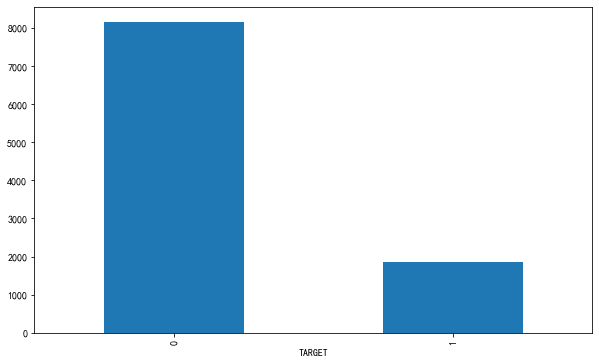

In [66]:
# 目标变量
yflag = 'TARGET'
plt.figure(figsize=(10,6))
df[yflag].value_counts(dropna=False).plot.bar()

In [67]:
df[yflag].value_counts(dropna=False,normalize=True)

TARGET
0    0.8149
1    0.1851
Name: proportion, dtype: float64

In [68]:
col = df.columns.difference([yflag,'ID'])
# 筛选float和int的数值类型变量
num_list = df[col].select_dtypes(include=['float','int64']).columns.tolist()
# 筛选ojbect字符型的数值类型变量
obj_list = df[col].select_dtypes(include=['object']).columns.tolist()
print('数值类型变量共',len(num_list))
print('object类型变量共',len(obj_list))

数值类型变量共 10
object类型变量共 0


# 2.决策树自动挖掘规则

In [69]:
# 输出每条决策树规则对应的最终预测值函数
def predict_value(tree):
    """
    :param tree: 决策树对象
    :return: 返回节点评估指标的列表
    """
    value_list = []
    tree_ = tree.tree_
    def recurse(node, depth):
        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            recurse(tree_.children_left[node], depth + 1)
            recurse(tree_.children_right[node], depth + 1)
        else:
            # 提取value中的正负样本
            good = tree_.value[node][0][0]
            bad  = tree_.value[node][0][1]
            samples = good+bad
            # 计算坏账率badrate
            bad_rate = round(bad*100/(bad+good),4)
            hit_rate = round(samples*100/total_sample,4)
            recall_rate = round(bad*100/total_bad,4)
            lift = round(bad_rate*0.01/total_badrate,4)
            
            value_list.append([bad_rate,hit_rate,recall_rate,lift])
    recurse(0, 1)
    return value_list

# 决策树规则抽取和解析函数
def extract_tree_rules(tree, feature_names):
    """
    :param tree:             决策树对象
    :param feature_names:    构建决策树使用的特征名称
    :return:                 决策树规则抽取结果
    """
    left = tree.tree_.children_left
    right = tree.tree_.children_right
    threshold = tree.tree_.threshold
    features = [feature_names[i] for i in tree.tree_.feature]
    index_list = np.argwhere(left == -1)[:, 0]
    value_list = predict_value(tree)
    rule_list = []
    # print(value_list)
    def decision_flow_extract(left, right, child, d_flow=None):
        """
        :param left:    数组格式，决策树左子节点id
        :param right:   数组格式，决策树右子节点id
        :param child:   子节点id
        :param d_flow:  子节点决策流
        :return:        子节点对应的决策流
        """
        if d_flow is None:
            d_flow = [child]
        if child in left:
            parent = np.where(left == child)[0].item()
            split = 'le'
        else:
            parent = np.where(right == child)[0].item()
            split = 'rg'
        d_flow.append((parent, split, threshold[parent], features[parent]))
        if parent == 0:
            d_flow.reverse()
            return d_flow
        else:
            return decision_flow_extract(left, right, parent, d_flow)
    rule_list=[]
    left_symbol = '<='
    rgiht_symbol = '>'
    for j, child in enumerate(index_list):
        clause = ''
        for node in decision_flow_extract(left, right, child):
            if len(str(node)) < 3:
                continue
            i = node
            if i[1] == 'le':
                sign = left_symbol
            else:
                sign = rgiht_symbol
            clause = clause + i[3] + sign + str(i[2]) + ' and '
        value_list[j].append(clause[:-4])
        # clause = clause[:-4] + ' Badrate:' + str(round(value_list[j],4))
        rule_list.append(value_list[j])
    return rule_list

## 2.1. 自动挖掘多变量规则

In [70]:
from itertools import combinations
def list_all_combinations(items, r):
    """
    列出所有大小为r的组合。
    :param items: 原始集合
    :param r: 组合的大小
    :return: 所有组合的列表
    """
    return list(combinations(items, r))
 
r = len(col)
rule_df_list = []

def rule_iter(n, max_d):
    """
    规则组合挖掘
    :param items: 
    :param n: 组合的大小
    :param max_d: 模型树深
    """
    combinations_list = list_all_combinations(col, n)
    for combo in combinations_list:
        X_ = df[list(combo)]
        y_ = df[yflag]
        # 划分数据集
        x_train,x_test,y_train,y_test=train_test_split(X_, y_, test_size=0.2, random_state=42)

        # 按照最优的方式分裂
        model=tree.DecisionTreeClassifier(
                                criterion="gini",
                                splitter='best',
                                random_state=2024,
                                max_depth=max_d,
                                min_samples_leaf=0.01,
                                min_samples_split=0.01)
        model = model.fit(x_train,y_train)

        # 统计训练集的总数量、坏客户数、坏客户浓度
        global total_bad 
        global total_badrate
        global total_sample
        total_bad = y_train.sum()
        total_badrate = y_train.mean()
        total_sample = y_train.count()
        
        # 调用决策树规则自动抽取函数进行规则抽取和解析
        rule_d = extract_tree_rules(tree=model, feature_names=X_.columns.tolist())

        # 输出抽取和解析的决策树规则
        rule_df = pd.DataFrame(rule_d,columns=['bad_rate','hit_rate','recall_rate','lift','rule_name'])
        rule_df_list.append(rule_df)

# 这里的两个参数可以调整
rule_iter(2, 1) # 单变量规则
rule_iter(r, 2) # 二维变量规则
rule_iter(r, 3) # 多维变量规则

In [71]:
df_mer = pd.concat(rule_df_list) # 拼接
df_dup = df_mer.drop_duplicates(subset=['rule_name']) # 去重
df_dup

,bad_rate,hit_rate,recall_rate,lift,rule_name
0,16.5934,93.8625,83.9623,0.8945,V01<=0.5
1,48.4725,6.1375,16.0377,2.6131,V01>0.5
0,93.3333,2.0625,10.3774,5.0314,V10<=491.5
1,16.9751,97.9375,89.6226,0.9151,V10>491.5
0,17.4111,95.9875,90.0943,0.9386,V02<=5.0
1,45.7944,4.0125,9.9057,2.4687,V02>5.0
0,26.1434,38.5375,54.3127,1.4093,V04<=5.0
1,13.7889,61.4625,45.6873,0.7433,V04>5.0
0,17.3851,97.1375,91.0377,0.9372,V05<=183.0
1,58.0786,2.8625,8.9623,3.1309,V05>183.0


要求单条规则**命中率不得超过5%，lift至少1以上**，因此对以上规则进行筛选

In [72]:
df_dup_ = df_dup[(df_dup['lift']>1)&(df_dup['hit_rate']<=5)].sort_values('bad_rate',ascending=False)
print(df_dup_.shape)
df_dup_.reset_index(drop=True)

(8, 5)


,bad_rate,hit_rate,recall_rate,lift,rule_name
0,97.5000,1.0000,5.2561,5.2561,V10<=491.5 and V01>0.5
1,93.3333,2.0625,10.3774,5.0314,V10<=491.5
2,89.4118,1.0625,5.1213,4.8200,V10<=491.5 and V01<=0.5
3,58.0786,2.8625,8.9623,3.1309,V05>183.0
4,58.0786,2.8625,8.9623,3.1309,V10>491.5 and V05>183.0
5,45.7944,4.0125,9.9057,2.4687,V02>5.0
6,45.7944,4.0125,9.9057,2.4687,V10>491.5 and V05<=183.0 and V02>5.0
7,35.8491,3.9750,7.6819,1.9326,V06>0.5


# 3.规则集性能测试

## 3.1.相互覆盖率

In [73]:
# 生成以上规则,默认值为0
dfc = df.copy() 
for n in range(0,df_dup_.shape[0]):
    dfc['rule'+str(n)] = 0

dfc['rule0'] = dfc['rule0'].mask((dfc['V10']<=491.5)&(dfc['V01']>0.5), other=1)
dfc['rule1'] = dfc['rule1'].mask((dfc['V10']<=491.5), other=1)
dfc['rule2'] = dfc['rule2'].mask((dfc['V10']<=491.5)&(dfc['V01']<=0.5), other=1)
dfc['rule3'] = dfc['rule3'].mask(dfc['V05']>183.0, other=1)
dfc['rule4'] = dfc['rule4'].mask((dfc['V10']>491.5)&(dfc['V05']>183.0), other=1)
# dfc['rule5'] = dfc['rule5'].mask(dfc['V01']>0.5, other=1)
dfc['rule5'] = dfc['rule5'].mask(dfc['V02']>5.0, other=1)
dfc['rule6'] = dfc['rule6'].mask((dfc['V10']>491.5)&(dfc['V05']<=183.0)&(dfc['V02']>5.0), other=1)
dfc['rule7'] = dfc['rule7'].mask(dfc['V06']>0.5, other=1)

In [74]:
# 相互覆盖率计算函数
def mutual_cover_rate(data,a,b):
    inner_hit = data[(data[a]==1)&(data[b]==1)].shape[0] #求交集数量
    a_innerhit_pct = round(inner_hit/data[(data[a]==1)].shape[0], 4) #交集命中占a总命中
    b_innerhit_pct = round(inner_hit/data[(data[b]==1)].shape[0], 4) #交集命中占b总命中
    return a_innerhit_pct,b_innerhit_pct

# 规则两两组合判断相互覆盖率
mutual_cover_info = []
for a,b in list_all_combinations([c for c in dfc.columns if 'rule' in c], 2):
    mutual_cover_info.append((a+','+b, a, mutual_cover_rate(dfc,a,b)[0]))
    mutual_cover_info.append((a+','+b, b, mutual_cover_rate(dfc,a,b)[1]))

# 相互覆盖率信息表
mutual_cover_df = pd.DataFrame(mutual_cover_info,columns=['grp','rule','mutual_cover_rate'])
mutual_cover_df.head(10)

,grp,rule,mutual_cover_rate
0,"rule0,rule1",rule0,1.0
1,"rule0,rule1",rule1,0.5
2,"rule0,rule2",rule0,0.0
3,"rule0,rule2",rule2,0.0
4,"rule0,rule3",rule0,0.0
5,"rule0,rule3",rule3,0.0
6,"rule0,rule4",rule0,0.0
7,"rule0,rule4",rule4,0.0
8,"rule0,rule5",rule0,0.0
9,"rule0,rule5",rule5,0.0


In [75]:
# 查看相互覆盖率为1的组合，以及被覆盖规则
mutual_cover_1 = mutual_cover_df[mutual_cover_df['mutual_cover_rate']==1]
mutual_cover_1['grp'] = mutual_cover_1['grp'].str.split(',')
mutual_cover_1_ex = mutual_cover_1.explode(['grp'])
mutual_cover_1_ex.groupby(['rule'])['grp'].apply(set).reset_index().sort_values(by=['grp'],ascending=False)

,rule,grp
0,rule0,"{rule0, rule1}"
1,rule2,"{rule1, rule2}"
2,rule3,"{rule3, rule4}"
3,rule4,"{rule3, rule4}"
4,rule5,"{rule6, rule5}"
5,rule6,"{rule6, rule5}"


In [76]:
del_rule = ['rule7','rule4','rule1','rule5']
df_rule = dfc[[c for c in dfc.columns.difference(del_rule) if 'rule' in c]]

## 3.2.单一命中率

In [77]:
rule_lst = df_rule.columns.tolist()
df_rule['hit_sum'] =  df_rule[rule_lst].sum(axis=1)
pure_hit_info = []
for col in rule_lst:
    hit_rate = round(df_rule[df_rule[col]==1].shape[0]/df_rule.shape[0],4)
    pure_hit_sum = df_rule[(df_rule[col]==1)&(df_rule['hit_sum']==1)].shape[0]
    pure_hit_rate = round(pure_hit_sum/df_rule.shape[0],4)
    pure_hit_info.append((col, hit_rate, pure_hit_rate))

pure_hit_df = pd.DataFrame(pure_hit_info, columns=['rule','hit_rate','pure_hit_rate'])
pure_hit_df

,rule,hit_rate,pure_hit_rate
0,rule0,0.0100,0.0100
1,rule2,0.0100,0.0100
2,rule3,0.0300,0.0300
3,rule6,0.0399,0.0399


## 3.3.综合命中率

In [78]:
# 规则命中数量分布
df_rule['hit_sum'].value_counts()

hit_sum
0    9101
1     899
Name: count, dtype: int64

In [79]:
df_rule['total_hit'] = df_rule['hit_sum'].map(lambda x:1 if x>=1 else 0)

In [80]:
df_rule['total_hit'].value_counts(normalize=True)

total_hit
0    0.9101
1    0.0899
Name: proportion, dtype: float64

## 3.4.整体坏账率

In [81]:
df_rule1 = dfc[rule_lst+[yflag]]
df_rule1['hit_sum'] =  df_rule1[rule_lst].sum(axis=1)
df_rule1['total_hit'] = df_rule1['hit_sum'].map(lambda x:1 if x>=1 else 0)
# 整体规则集命中样本的坏账率
df_rule1[(df_rule1['total_hit']==1)&(df_rule1['TARGET']==1)].shape[0]/df_rule1[df_rule1['total_hit']==1].shape[0] 

0.5951056729699666

In [82]:
total_badrate

0.1855

In [83]:
# lift
0.5951/0.1855

3.208086253369272

# 番外

如果对pandas不熟悉想要进阶的朋友可以了解下东哥的这个原创笔记，已经完全体，后续随着版本迭代会持续更新。

[《pandas进阶宝典》](https://app7hmmvkwr2019.h5.xiaoeknow.com/p/course/ecourse/course_2YD5u0x8FzrAIyM8soEuxnTkP9r)永久访问权限，500页图文笔记，近30万字，配套完整代码支持下载。

5大核心图文，具体包括：
- 《pandas快速入门》
- 《pandas进阶宝典》
- 《pandas实战项目》
- 《pandas进阶题库》
- 《Numpy速查手册》
- 《正则表达式手册》

感兴趣可以扫码了解，或者加我微信可以有折扣，加V：`Petery_1966`

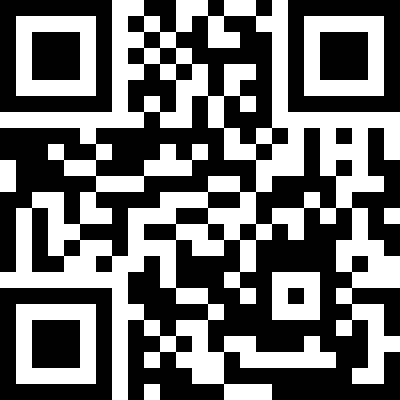